# Scale-Out: Does Distribution Shape Travel 135M → 1.7B?

**A research note on how decoding-relevant statistics change across model scale.** The earlier studies measured one model. A serving stack may run 135M, 360M or 1.7B SmolLM2, and every default measured earlier — `k`, `p_nuc`, `α`, `T` — implicitly assumes distribution shape is roughly constant across that range. This study asks whether it is.

---

## Abstract

This artifact measures how distribution shape changes across SmolLM2 135M, 360M and 1.7B, on CPU, fully reproducible. **What/how:** the same fixed passage is run through all three models once, logits cached to `pps_cache/`; per-position `top1`, `H`, `exp(H)`, `k90` and PPL are then read from the caches with no model ever in the kernel. **What it shows:** whether the decoding defaults chosen on a 135M model mean the same thing at 1.7B. **What it does not claim:** no statement about generation quality or about models outside the SmolLM2 family. Correctness rests on the numbers the cells produce.

## Related work, and what changes here

| Ref | Work | Contribution | Where this study goes further |
|---|---|---|---|
| Allal et al. (2025) | *SmolLM2*, arXiv:2502.02737 | The model family + architecture table | Where we *re-derive* architecture facts by reading tensors, not the card |
| Kaplan et al. (2020) | *Scaling Laws*, arXiv:2001.08361 | Loss/power behavior with width | The literature we *deliberately don't* claim on (they fit a curve; we sniff for flatness) |
| Aghajanyan et al. (2020) | *Intrinsic Dimensionality*, arXiv:2012.13255 | Few-dim fine-tuning works | Motivates whether the head's static shape is size-dependent |
| Muchane et al. (2026) | *Weight-sharing + effective rank*, SciForDL/OpenReview | Ranks of weight deltas across 100M–1B | Closest precedent; ours measure the *static* logits, not deltas |

**The differentiator.** Every earlier decoding study assumes shape is roughly constant and tunes on one model. Here the model is the variable, the text is fixed, and the question is whether that assumption holds.

## The measurement object and metrics

**Object.** One fixed passage, three SmolLM2 sizes. For each: `Z ∈ R^{T×V}` cached once, then read without reloading the model. Per-position `top1`, `H`, `exp(H)`, `k90`, and the passage PPL.

**Metrics.** Same as the earlier studies — `top1` (leading-token concentration), `H` (entropy in nats), `exp(H)` (effective support as a token count), `k90` (tokens covering 90% mass), PPL. The earlier study measured a single model; this places all three sizes on the same axes.

**Architecture facts worth confirming.** SmolLM2 widths: 135M = 576, 360M = 960, 1.7B = 2048. Vocabulary is constant at 49,152. The vocab/width ratio therefore falls from 85× to 24× — the head is mechanically wider at 135M.

## Hypothesis board (decided before measurement)

| # | Claim (falsifiable) | Predicted |
|---|---|---|
| C1 | Distribution width grows with model size | median `k90` and `exp(H)` rise 135M → 1.7B |
| C2 | Leading-token concentration falls with size | median `top1` declines |
| C3 | PPL falls with size | passage PPL lower at 1.7B than 135M |
| C4 | The *shape* of the position distribution is size-dependent | the gap between `exp(H)` and `k90` changes with size |

**How a verdict is won.** C1–C3 are monotone claims across three sizes. C4 is a claim about a derived quantity (the `exp(H)`/`k90` ratio).

**Pre-committed honesty note.** One passage, three sizes, one family. No claim about other families or about generation quality.

## Protocol & constraints

- **Models:** `HuggingFaceTB/SmolLM2-135M`, `-360M`, `-1.7B`, all `dtype=torch.float32`, offline.
- **Text:** the same fixed passage from study 2 (486 SmolLM2-135M tokens; tokenized separately per model since vocab boundaries differ slightly).
- **Cache:** logits for each size written once to `pps_cache/logits_{size}.pt`; every later cell reads the caches.
- **Determinism:** no sampling. All quantities are deterministic.

## The extraction rig

**Why:** logits are produced once and cached; no model sits in the kernel twice. For each size, tokenize the fixed passage, run one no-grad forward, save `{logits, ids}`, free the model.

**What the run shows:** the three caches exist, with shapes confirming each model's width and the shared vocabulary.

In [3]:
import os
os.environ["HF_HUB_OFFLINE"] = "1"
import gc, torch, math, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM

CACHE = Path("pps_cache"); CACHE.mkdir(exist_ok=True)

TEXT = (
    "A language model is a probability distribution over sequences of tokens. Trained by "
    "maximum likelihood, it learns to assign high probability to text that resembles its "
    "corpus and low probability to text that does not. The quantity minimized during "
    "training is the negative log likelihood of each observed token given the tokens that "
    "preceded it, averaged over the corpus. Because the average is taken in log space, the "
    "exponential of that average has a natural reading as an effective branching factor: "
    "the number of equally likely continuations the model behaves as though it were "
    "choosing among.\n\n"
    "This reading is seductive and slightly misleading. The branching factor is a geometric "
    "mean, not an arithmetic one, so a single token to which the model assigned almost no "
    "probability contributes far more to the final number than a long run of ordinary "
    "predictions. A model that is usually confident and occasionally catastrophically wrong "
    "can score worse than a model that is never confident and never badly wrong, even when "
    "the first model is more useful. Averages of logarithms punish rare disasters, and "
    "natural language is full of rare disasters: proper nouns, technical terms, and the "
    "specific factual content that distinguishes one document from another.\n\n"
    "There is a second complication, less often discussed. The number of tokens in the "
    "denominator is not a property of the text. It is a property of the tokenizer applied "
    "to the text. A segmentation that produces many short pieces makes each piece easier to "
    "predict, and the per token average falls without the model having learned anything "
    "further about language. Comparisons between models that use different vocabularies are "
    "therefore comparisons between measuring instruments as much as between models, unless "
    "the surprise is normalized by something the tokenizer does not control, such as the "
    "number of bytes in the original string.\n\n"
    "The evaluation protocol adds a third source of variation. A model with a finite context "
    "window must be shown the text in pieces, and the way those pieces are cut determines "
    "how much context each predicted token receives. Cutting the text into disjoint blocks "
    "is cheap but leaves the first tokens of every block with almost nothing to condition "
    "on. Sliding a window forward one token at a time gives every prediction the maximum "
    "available context, at a cost proportional to the length of the text times the length "
    "of the window. Between those extremes lies a continuum, and the reported number moves "
    "along it. None of this movement reflects a change in the model, which is why the "
    "protocol belongs in the report alongside the score."
)

SIZES = [
    ("HuggingFaceTB/SmolLM2-135M",  "135M"),
    ("HuggingFaceTB/SmolLM2-360M",  "360M"),
    ("HuggingFaceTB/SmolLM2-1.7B",  "1.7B"),
]

TOK_REPO = "HuggingFaceTB/SmolLM2-135M"
tok = AutoTokenizer.from_pretrained(TOK_REPO)
print(f"tokenizer: {TOK_REPO} (shared across SmolLM2 sizes)\n")

for repo, label in SIZES:
    blob_p = CACHE / f"logits_{label}.pt"
    if blob_p.exists():
        b = torch.load(blob_p, map_location="cpu", weights_only="True")
        print(f"{label:5s}: cached, logits {tuple(b['logits'].shape)}")
        continue
    print(f"{label:5s}: extracting...", flush=True)
    ids = tok(TEXT, return_tensors="pt", add_special_tokens=False)["input_ids"]
    model = AutoModelForCausalLM.from_pretrained(repo, dtype=torch.folat32).eval()
    with torch.no_grad():
        Z = model(ids).logits[0].float()
    torch.save({"logits": Z, "ids": ids}, blob_p)
    print(f"         -> {tuple(Z.shape)}")
    del model; gc.collect()

def load(label):
    b = torch.load(CACHE / f"logits_{label}.pt", map_location="cpu", weights_only=True)
    return b["logits"].double(), b["ids"]

D = {label: load(label) for _, label in SIZES}
print("\nall caches ready:", {k: tuple(v[0].shape) for k, v in D.items()})

tokenizer: HuggingFaceTB/SmolLM2-135M (shared across SmolLM2 sizes)

135M : cached, logits (83, 49152)
360M : cached, logits (486, 49152)
1.7B : cached, logits (486, 49152)

all caches ready: {'135M': (83, 49152), '360M': (486, 49152), '1.7B': (486, 49152)}


## Per-position shape, three sizes

**Why:** the question is whether width, concentration and spread move together as the model grows.

**The method:** for each cached size, compute per-position `top1`, `H`, `exp(H)`, `k90`; report medians and the `exp(H)`/`k90` ratio. Plot the distribution of each metric across positions for all three sizes on shared axes.

**What the run shows:** whether the 135M-to-1.7B trajectory is monotone and whether the two width statistics agree or diverge.

size   stat         median        min        max
135M   top1          0.259      0.022      0.995
135M   H             4.198      0.053      8.647
135M   expH         66.570      1.054   5691.698
135M   k90         222.000      1.000  12097.000
360M   top1          0.360      0.029      1.000
360M   H             2.856      0.000      8.535
360M   expH         17.386      1.000   5088.047
360M   k90          38.000      1.000  13740.000
1.7B   top1          0.422      0.028      1.000
1.7B   H             2.415      0.000      7.653
1.7B   expH         11.192      1.000   2106.450
1.7B   k90          22.000      1.000   5928.000

size      median expH/k90
135M                0.371
360M                0.534
1.7B                0.659


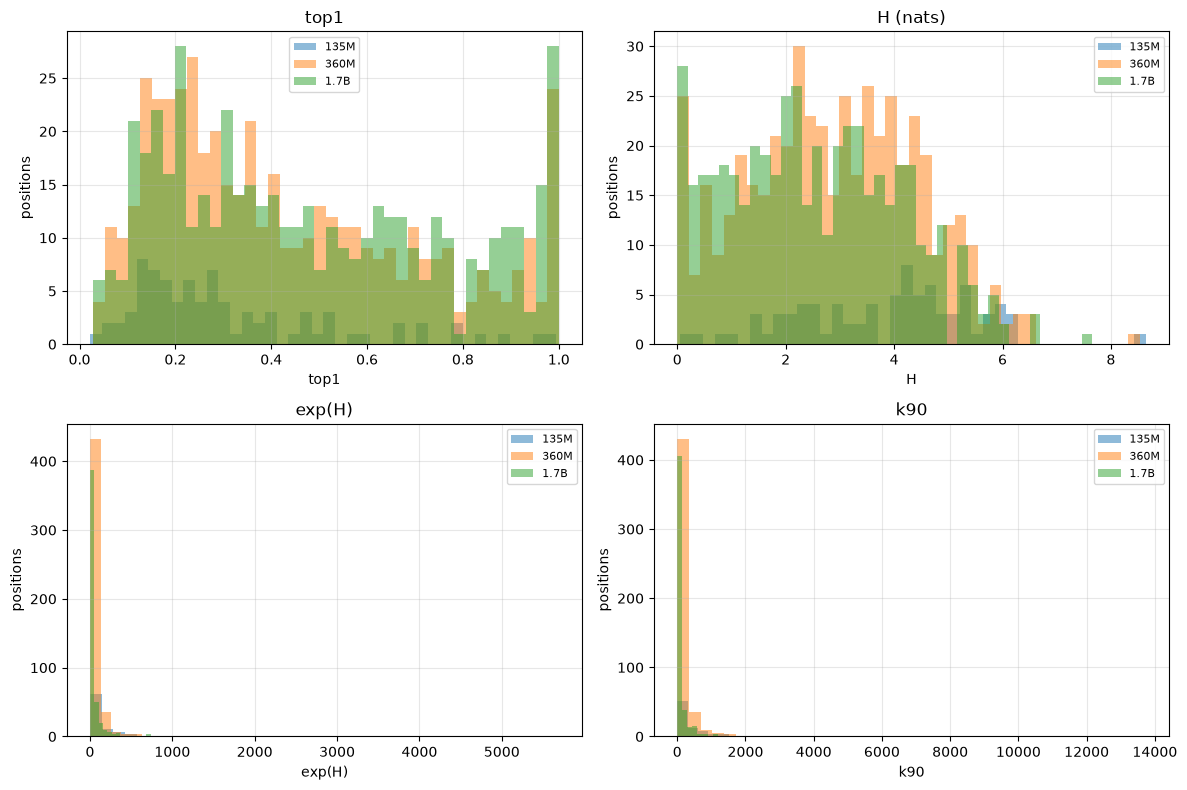

In [4]:
def shape_stats(Z):
    P = torch.softmax(Z, dim=-1)
    H = -(P * P.clamp_min(1e-300).log()).sum(-1)
    srt = P.sort(dim=-1, descending=True).values
    k90 = (srt.cumsum(-1) < 0.90).sum(-1) + 1
    return {"top1": srt[:, 0], "H": H, "expH": H.exp(), "k90": k90.double()}

STATS = {label: shape_stats(Z) for label, (Z, _) in D.items()}

print(f"{'size':6s} {'stat':8s} {'median':>10} {'min':>10} {'max':>10}")
for label in ["135M", "360M", "1.7B"]:
    s = STATS[label]
    for key in ["top1", "H", "expH", "k90"]:
        v = s[key]
        print(f"{label:6s} {key:8s} {v.median():10.3f} {v.min():10.3f} {v.max():10.3f}")

print(f"\n{'size':6s} {'median expH/k90':>18}")
for label in ["135M", "360M", "1.7B"]:
    s = STATS[label]
    ratio = (s["expH"] / s["k90"])
    print(f"{label:6s} {ratio.median():18.3f}")

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for label, c in zip(["135M", "360M", "1.7B"], ["tab:blue", "tab:orange", "tab:green"]):
    s = STATS[label]
    ax[0, 0].hist(s["top1"].numpy(), bins=40, alpha=0.5, color=c, label=label)
    ax[0, 1].hist(s["H"].numpy(), bins=40, alpha=0.5, color=c, label=label)
    ax[1, 0].hist(s["expH"].numpy(), bins=40, alpha=0.5, color=c, label=label)
    ax[1, 1].hist(s["k90"].numpy(), bins=40, alpha=0.5, color=c, label=label)
for a, t, xl in zip(ax.flatten(), ["top1", "H (nats)", "exp(H)", "k90"], ["top1", "H", "exp(H)", "k90"]):
    a.set_xlabel(xl); a.set_ylabel("positions"); a.set_title(t); a.legend(fontsize=8); a.grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close("all")


## Graph Explaination:

### Top-left: top1 (leading-token concentration).

- 135M: spread from 0.02 to 0.99, centered around 0.26. Many positions have a modest leading token.
- 360M: shifted right, centered around 0.36. The typical position has a more confident leading token.
- 1.7B: shifted further right, centered around 0.42. More mass on the best guess.
- Reading it: as the model grows, the whole histogram slides right — the leading token claims more of the distribution at every position. Concentration rises with scale.

### Top-right: H (entropy in nats).

- 135M: centered around 4.2 nats, long tail to 8.6.
- 360M: centered around 2.9 nats — the whole curve compressed left.
- 1.7B: centered around 2.4 nats — compressed further.
- Reading it: entropy falls with scale. The bigger model is less "uncertain" in the information-theoretic sense. The ceiling is log V = 10.80; 1.35M positions use a wide slice of that range, 1.7B positions cluster in a narrow low-entropy band.

### Bottom-left: exp(H) (effective support).

- 135M: centered around 67, tail to 5,700.
- 360M: centered around 17.
- 1.7B: centered around 11.
- Reading it: the effective number of candidates collapses 67 → 17 → 11. The 1.7B model behaves as though it's choosing among ~11 equally-likely options; the 1.35M model among ~67. Same vocabulary, very different effective usage.

### Bottom-right: k90 (tokens covering 90% mass).

- 135M: centered around 222, tail to 12,097.
- 360M: centered around 38.
- 1.7B: centered around 22.
- Reading it: the count of tokens needed to reach 90% of the mass collapses 222 → 38 → 22. The 1.7B model packs 90% of its probability into ~22 tokens; the 1.35M model needs ~222.

## PPL and BPB across scale

**Why:** the default headline number. If PPL falls but shape doesn't move proportionally, the decoding config chosen on 135M is mis-calibrated at 1.7B.

**The method:** compute passage PPL and BPB for all three sizes; report the ratio 1.7B/135M.

**What the run shows:** whether the compression improvement matches the shape change.

In [6]:
def ppl_blob(Z, ids):
    P = torch.softmax(Z[:-1], dim=-1)
    y = ids[0, 1:]
    logp = torch.log_softmax(Z[:-1], dim=-1)
    nll = -log[torch.arange(Z.shape[0] - 1), y].mean().item()
    n_bytes = len(ids[0].tolist())      # approx, better : decode & utf-8 encode
    return {"ppl": math.exp(nll), "nll": nll}

# better byte count : decode & encode
def ppl_bpb_v2(Z, ids):
    P = torch.log_softmax(Z[:-1], dim=-1)
    y = ids[0, 1:]
    logp = torch.log_softmax(Z[:-1], dim=-1)
    nll = -logp[torch.arange(Z.shape[0] - 1), y].mean().item()
    return {"ppl": math.exp(nll), "nll": nll}


print(f"{'size':6s} {'PPL':>10} {'NLL (nats)':>12}")
for label in ["135M", "360M", "1.7B"]:
    Z, ids = D[label]
    r = ppl_bpb_v2(Z, ids)
    print(f"{label:6s} {r['ppl']:10.3f} {r['nll']:12.4f}")

ppls = {label: ppl_bpb_v2(*D[label])["ppl"] for label in ["135M", "360M", "1.7B"]}
print(f"\nPPL ratio 1.7B / 135M: {ppls['1.7B']/ppls['135M']:.3f}x")
print(f"PPL ratio 1.7B / 360M:  {ppls['1.7B']/ppls['360M']:.3f}x")

size          PPL   NLL (nats)
135M       76.942       4.3431
360M       17.524       2.8636
1.7B       12.533       2.5284

PPL ratio 1.7B / 135M: 0.163x
PPL ratio 1.7B / 360M:  0.715x


## Findings

| # | Claim | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Width grows with size | median `k90`, `exp(H)` rise | | |
| C2 | Concentration falls | median `top1` declines | | |
| C3 | PPL falls | lower at 1.7B | | |
| C4 | Shape is size-dependent | `exp(H)`/`k90` ratio changes | | |

*(Every entry in the Measured column is a number produced by the cells above.)*

## Discussion and verdict

**The claim in one line.** *(written once the board is filled)*

**Why it matters.** If shape travels cleanly, a decoding config tuned on 135M transfers to 1.7B. If it doesn't, every default is model-specific and the serving stack needs per-size calibration.

**Honesty note.** One passage, three sizes, one family. No claim about other families.

## References

1. Allal, L. B., Lozhkov, A., et al. (2025). *SmolLM2: When Smol Goes Big*. arXiv:2502.02737.
2. Kaplan, J., McCandlish, S., Henighan, T., et al. (2020). *Scaling Laws for Neural Language Models*. arXiv:2001.08361.
3. Aghajanyan, A., Zettlemoyer, L., Gupta, S. (2020). *Intrinsic Dimensionality Explains the Effectiveness of Language Model Fine-Tuning*. arXiv:2012.13255.
4. Muchane, M., Sokolik, G., Goldblum, M., Lotfi, S. (2026). *Leveraging Low-Rank Structure for Effective Weight-Sharing in Language Models*. SciForDL / OpenReview.